# Анализ продаж интернет-магазина


# Содержание

1. Цель проекта
2. Загрузка данных
3. Исследование структуры данных
4. Очистка данных
5. Основные KPI
6. Анализ категорий товаров
7. Анализ регионов
8. Анализ скидок
9. Анализ сезонности
10. Анализ клиентов
11. Итоговые выводы
12. Рекомендации бизнесу


## Цель проекта

Провести исследовательский анализ данных интернет-магазина, выявить факторы, влияющие на продажи и прибыль, а также сформулировать рекомендации для бизнеса.

## Используемые инструменты

- Python
- Pandas
- NumPy
- Matplotlib

# Загрузка данных

В качестве источника используется датасет **Sample Superstore**, содержащий информацию о заказах интернет-магазина.

Датасет включает сведения о клиентах, товарах, продажах, прибыли, скидках и регионах

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

pd.set_option("display.max_columns", None)

In [31]:
df = pd.read_csv("Sample - Superstore.csv", encoding='windows-1252')


## Первичный просмотр данных

Ознакомимся со структурой набора данных и убедимся, что столбцы содержат ожидаемую информацию.

In [42]:

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October


In [43]:
df.shape

(9994, 24)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

### Вывод

Датасет содержит **9994 записи** и **21 признак**.

Типы данных в целом корректны, однако столбцы **Order Date** и **Ship Date** требуют преобразования в формат datetime.

In [45]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
Month Name       0
dtype: int64

In [46]:
df.duplicated().sum()

0

In [47]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [48]:
df["Order Date"].dt.year

0       2016
1       2016
2       2016
3       2015
4       2015
        ... 
9989    2014
9990    2017
9991    2017
9992    2017
9993    2017
Name: Order Date, Length: 9994, dtype: int32

In [49]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [51]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Year,Month
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654


## Выводы по качеству данных

- Пропущенные значения отсутствуют.
- Полных дубликатов не обнаружено.
- Типы данных приведены к корректному виду.
- Распределение продаж имеет выраженную правостороннюю асимметрию: большинство заказов имеют небольшую стоимость, но встречаются крупные покупки.
- В данных присутствуют как высокоприбыльные, так и убыточные заказы.
- Максимальная скидка составляет 80 %, что может существенно влиять на прибыльность продаж.

# Бизнес-вопросы

В рамках проекта необходимо ответить на следующие вопросы:

1. Каковы основные показатели эффективности магазина?
2. Какие категории и подкатегории товаров приносят наибольшую прибыль?
3. Какие регионы и штаты являются наиболее прибыльными?
4. Как скидки влияют на прибыль?
5. Наблюдается ли сезонность продаж?
6. Кто является наиболее ценными клиентами?
7. Какие рекомендации можно дать бизнесу по результатам анализа?

# Основные показатели деятельности магазина

In [52]:
# Общая выручка
total_sales = df["Sales"].sum()

# Общая прибыль
total_profit = df["Profit"].sum()

# Количество заказов
orders = df["Order ID"].nunique()

# Количество клиентов
customers = df["Customer ID"].nunique()

# Средняя сумма продажи
average_sale = df["Sales"].mean()

print(f"Общая выручка: ${total_sales:,.2f}")
print(f"Общая прибыль: ${total_profit:,.2f}")
print(f"Количество заказов: {orders}")
print(f"Количество клиентов: {customers}")
print(f"Средняя сумма продажи: ${average_sale:.2f}")

Общая выручка: $2,297,200.86
Общая прибыль: $286,397.02
Количество заказов: 5009
Количество клиентов: 793
Средняя сумма продажи: $229.86


In [53]:
kpi = pd.DataFrame({
    "Показатель": [
        "Общая выручка",
        "Общая прибыль",
        "Количество заказов",
        "Количество клиентов",
        "Средняя сумма продажи"
    ],
    "Значение": [
        round(total_sales, 2),
        round(total_profit, 2),
        orders,
        customers,
        round(average_sale, 2)
    ]
})

kpi

,Показатель,Значение
0,Общая выручка,2297200.86
1,Общая прибыль,286397.02
2,Количество заказов,5009.00
3,Количество клиентов,793.00
4,Средняя сумма продажи,229.86


# Анализ категорий товаров

Цель раздела — определить, какие категории товаров обеспечивают наибольшую выручку и прибыль.

In [54]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [55]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

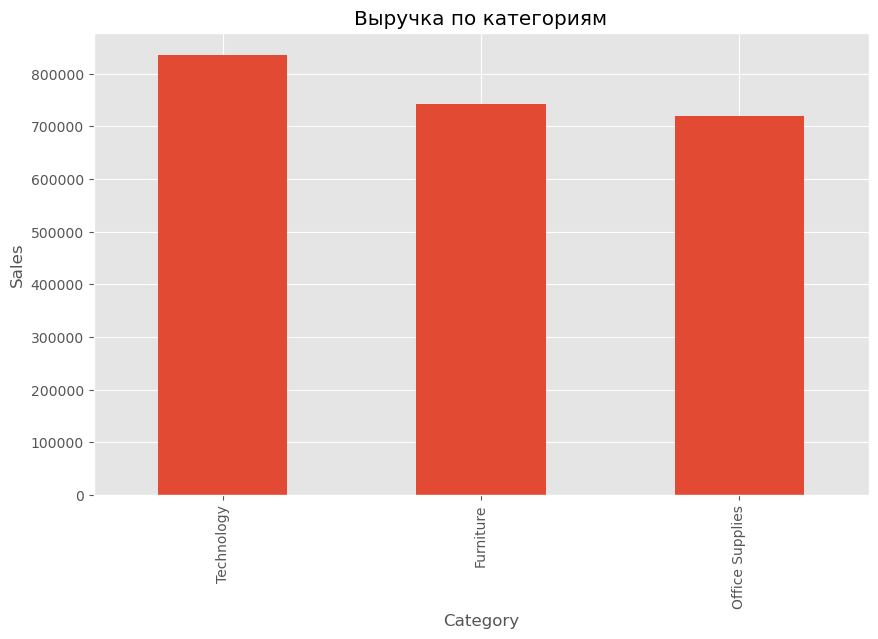

In [56]:
category_sales.plot(
    kind="bar",
    title="Выручка по категориям"
)

plt.ylabel("Sales")
plt.show()

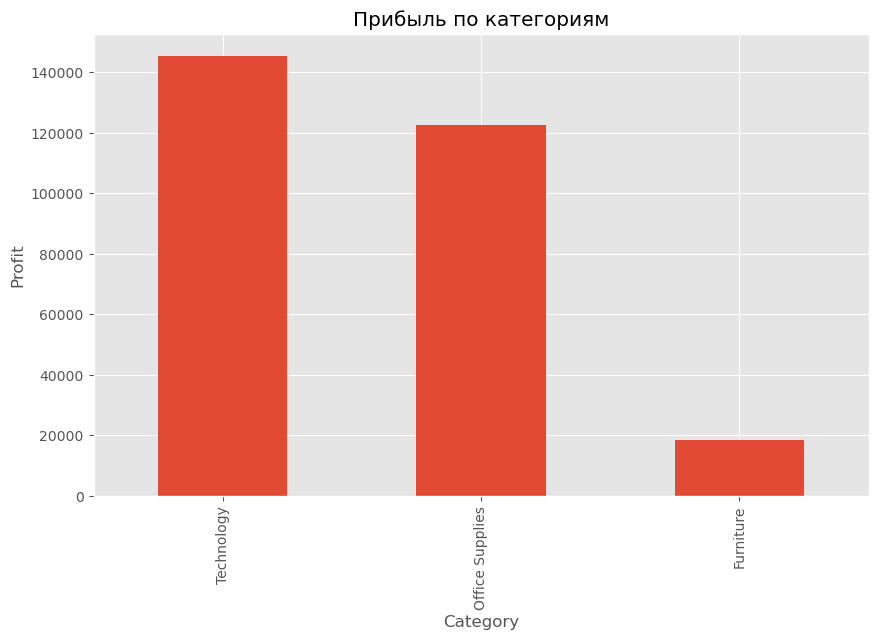

In [57]:
category_profit.plot(
    kind="bar",
    title="Прибыль по категориям"
)

plt.ylabel("Profit")
plt.show()

### Вывод

Категория Technology обеспечивает наибольшую прибыль компании.

Категория Furniture имеет высокую выручку, однако её прибыль значительно ниже, что может быть связано с высокой себестоимостью или предоставлением крупных скидок.

Рекомендуется подробнее исследовать причины низкой прибыльности категории Furniture.

In [ ]:
Ы